In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
import os
print(os.getcwd())

C:\Users\DELL\Downloads


In [3]:
# If it's a .csv file
path = "Sales_Analysis.csv"
Sales_Analysis = pd.read_csv(path)



In [4]:
Sales_Analysis.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month', 'Month_Name', 'Year'],
      dtype='str')

In [5]:
## Checking Duplicates

In [6]:
Sales_Analysis.duplicated().sum()

np.int64(0)

No Duplicates 

In [7]:
## Checking Null Values

In [8]:
Sales_Analysis.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Month            0
Month_Name       0
Year             0
dtype: int64

In [9]:
null_replace = ['Postal Code']
Sales_Analysis[null_replace]=Sales_Analysis[null_replace].fillna('Not Mentioned')
Sales_Analysis.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Month            0
Month_Name       0
Year             0
dtype: int64

In [10]:
Sales_Analysis.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month', 'Month_Name', 'Year'],
      dtype='str')

In [11]:
## Category Wise Sales And Average Sales

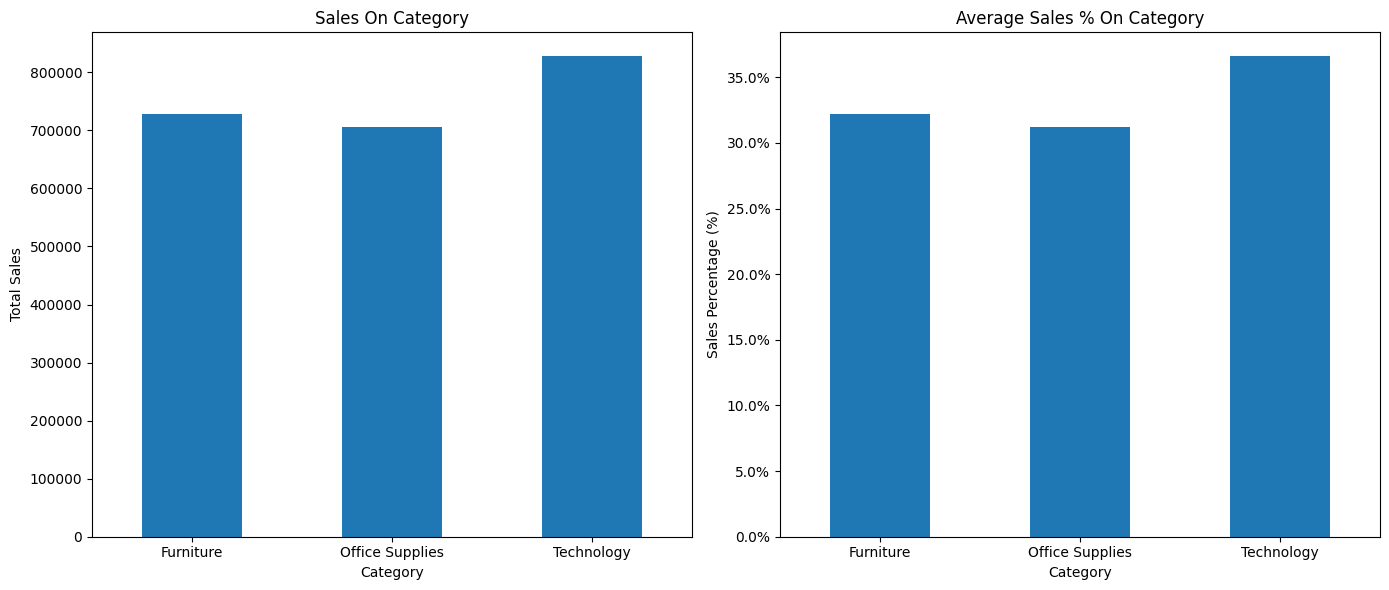

Category
Furniture          728658.58
Office Supplies    705422.33
Technology         827455.87
Name: Sales, dtype: float64
Category
Furniture          32.22
Office Supplies    31.19
Technology         36.59
Name: Sales, dtype: float64


In [12]:
total_Sales= Sales_Analysis['Sales'].sum()
Category_Sales=Sales_Analysis.groupby('Category')['Sales'].sum().round(2)
Category_AvgSales_pct=((Category_Sales/total_Sales)*100).round(2)
fig,axis=plt.subplots(1,2,figsize=(14,6))
Category_Sales.plot(kind='bar',ax=axis[0])
axis[0].set_title('Sales On Category')
axis[0].set_xlabel('Category')
axis[0].set_ylabel('Total Sales')
axis[0].tick_params(axis='x',rotation=0)
Category_AvgSales_pct.plot(kind='bar',ax=axis[1])
axis[1].set_title('Average Sales % On Category')
axis[1].set_xlabel('Category')
axis[1].set_ylabel('Sales Percentage (%)')
axis[1].tick_params(axis='x',rotation=0)
axis[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()
print(Category_Sales)
print(Category_AvgSales_pct)

# Insights:
 #  Sales:
        Technology Category has  highest Sales Aprox( Sales=8,27,455.87) and its average sale percentage is 36.59%
        Office Supplies has  Lowest  Sales Aprox( Sales=7,05,422.33) and its average sale percentage is 31.19%
 NOTE: 
  second highest sales Furniture with Sale of 7,28,658.58 and least selling category Office Supplies has selling 7,05,422.33. their average difference is 1.03% . 

In [13]:
## Region Wise Sales and average rate

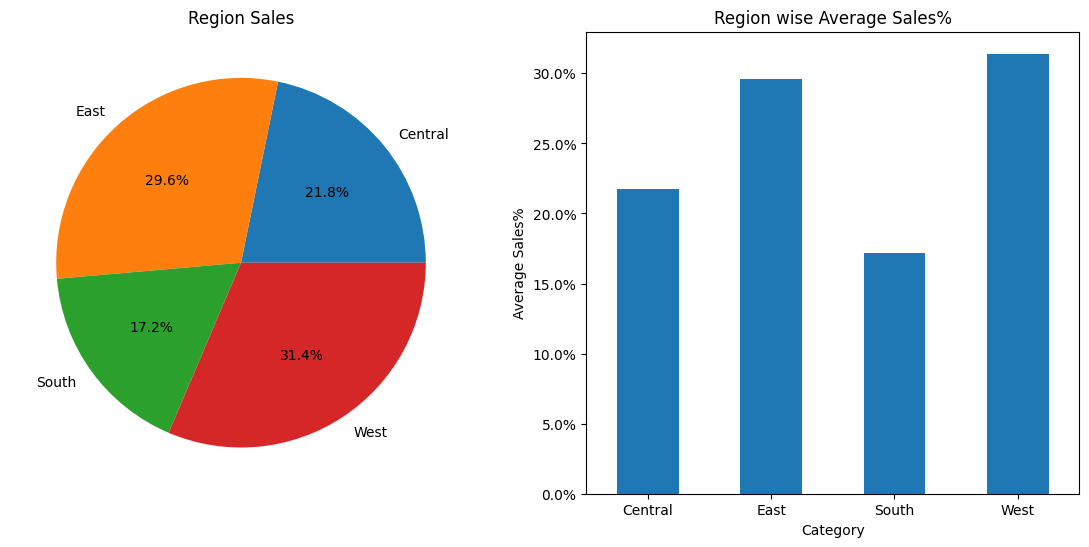

Region
Central    21.78
East       29.60
South      17.21
West       31.40
Name: Sales, dtype: float64
Region
Central    492646.91
East       669518.73
South      389151.46
West       710219.68
Name: Sales, dtype: float64


In [14]:
Region_Sales=Sales_Analysis.groupby('Region')['Sales'].sum().round(2)
Region_avg_Sales=((Region_Sales/total_Sales)*100).round(2)
fig,axis=plt.subplots(1,2,figsize=(14,6))
Region_Sales.plot(kind='pie', ax=axis[0], autopct='%1.1f%%')
axis[0].set_title('Region Sales')
Region_avg_Sales.plot(kind='bar',ax=axis[1])
axis[1].set_title('Region wise Average Sales%' )
axis[1].set_xlabel('Category')
axis[1].set_ylabel('Average Sales%')
axis[1].tick_params(axis='x',rotation=0)
axis[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.show()
print(Region_avg_Sales)
print(Region_Sales)

# Insights:
   ## Region Sales:
        West Region has Highest Sales Values aprox(Sales= 7,10,219.68) with 31.40% of average sales 
        South Region Has Lowest Sales Values aprox(Sales=3,89,151.46) with  17.21% of average sales 

In [15]:
## Top 10 City Among Sales 

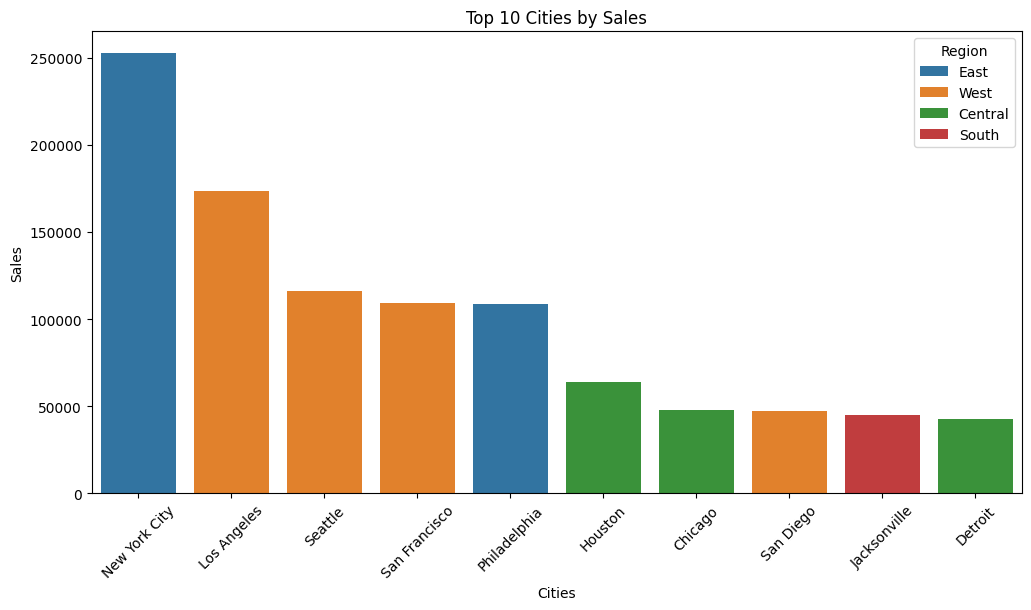

              City   Region      Sales
365  New York City     East  252462.55
299    Los Angeles     West  173420.18
496        Seattle     West  116106.32
482  San Francisco     West  109041.12
413   Philadelphia     East  108841.75
232        Houston  Central   63956.14
89         Chicago  Central   47820.13
481      San Diego     West   47521.03
243   Jacksonville    South   44713.18
141        Detroit  Central   42446.94


In [16]:
City_Sales = Sales_Analysis.groupby(['City','Region'])['Sales'].sum().round(2).reset_index()
City_Sales=City_Sales.sort_values('Sales',ascending=False).head(10)
plt.figure(figsize=(12,6))
ax=sns.barplot(data=City_Sales,x='City',y='Sales',hue='Region')
ax.set_title('Top 10 Cities by Sales')
ax.set_xlabel('Cities')
ax.set_ylabel('Sales')
ax.tick_params(axis='x',rotation=45)
plt.show()
print(City_Sales)

Insights:
 In UnitedStates Country New York City Has Highest Sales in East Region (Sales =2,52,462.55)  
 

In [17]:
## Last 10 City Among Sales 

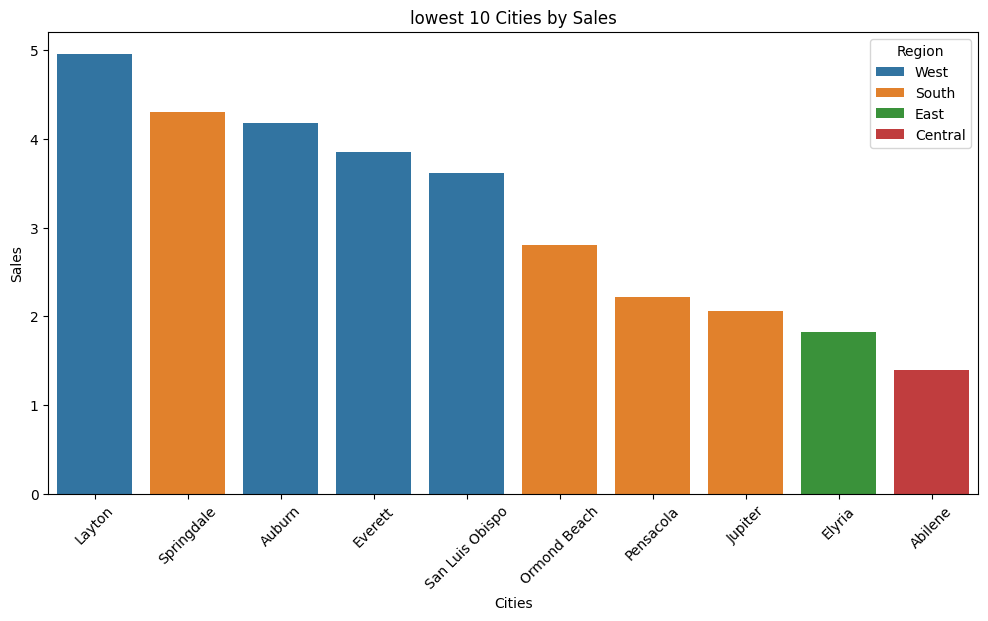

                City   Region  Sales
281           Layton     West  4.960
507       Springdale    South  4.300
27            Auburn     West  4.180
166          Everett     West  3.856
485  San Luis Obispo     West  3.620
391     Ormond Beach    South  2.808
408        Pensacola    South  2.214
248          Jupiter    South  2.064
159           Elyria     East  1.824
1            Abilene  Central  1.392


In [18]:
lowest_SaleCity=Sales_Analysis.groupby(['City','Region'])['Sales'].sum().reset_index()
lowest_SaleCity=lowest_SaleCity.sort_values('Sales',ascending=False).tail(10)
plt.figure(figsize=(12,6))
ax=sns.barplot(data=lowest_SaleCity,x='City',y='Sales',hue='Region')
ax.set_title('lowest 10 Cities by Sales')
ax.set_xlabel('Cities')
ax.set_ylabel('Sales')
ax.tick_params(axis='x',rotation=45)
plt.show()
print(lowest_SaleCity)

Insights:
  In united States country  Abilene City has lowest Sales from Central (Sales= 1.39)
Note:
  last 10 city recorded Sales (below 5)

In [19]:
##Category Wise Sales at City

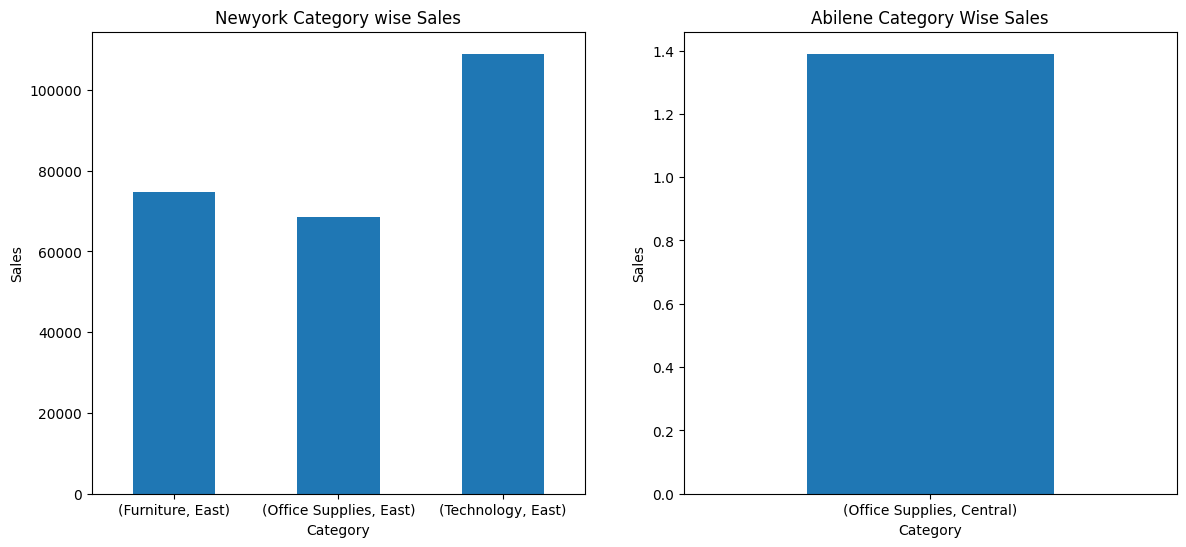

Category         Region
Furniture        East       74822.88
Office Supplies  East       68659.53
Technology       East      108980.14
Name: Sales, dtype: float64
Category         Region 
Office Supplies  Central    1.39
Name: Sales, dtype: float64


In [20]:
NewYork_Sales = Sales_Analysis[Sales_Analysis['City'] == 'New York City'].groupby(['Category','Region'])['Sales'].sum().round(2)
Abilene_Sales= Sales_Analysis[Sales_Analysis['City']=='Abilene'].groupby(['Category','Region'])['Sales'].sum().round(2)
fig,axis=plt.subplots(1,2,figsize=(14,6))
NewYork_Sales.plot(kind='bar',x='Category',y='Sales',ax=axis[0])
axis[0].set_title('Newyork Category wise Sales')
axis[0].set_xlabel('Category')
axis[0].set_ylabel('Sales')
axis[0].tick_params(axis='x',rotation=0)
Abilene_Sales.plot(kind='bar',x='Category',y='Sales',ax=axis[1])
axis[1].set_title('Abilene Category Wise Sales')
axis[1].set_xlabel('Category')
axis[1].set_ylabel('Sales')
axis[1].tick_params(axis='x',rotation=0)
plt.show()
print(NewYork_Sales)
print(Abilene_Sales)

In [21]:
NewYork_Sales=Sales_Analysis[Sales_Analysis['City']=='New York City'].groupby('Region')['Sales'].sum().round(2)
print(NewYork_Sales)

Region
East    252462.55
Name: Sales, dtype: float64


Insights:
   *. NewYork City Has High Sales (Sales=2,52,462.55) in that Technology category has highest Sales At East region (Sales=1,08,980.14)
     Furniture Category 2nd Highest Sales Also at East region (Sales=74,822.88),Office Supplies last at new york Sales of 68,659.53 from east region
   *. In United Sates Country Abilene City Has Lowest Among all which Has generated only Sale of 1.39 from office Supplies from Central Region 
  NOTE:
  Though NewYork has highest Sale (Sales=2,52,462.55) is all generated from same region on East.  

In [22]:
##Customer :


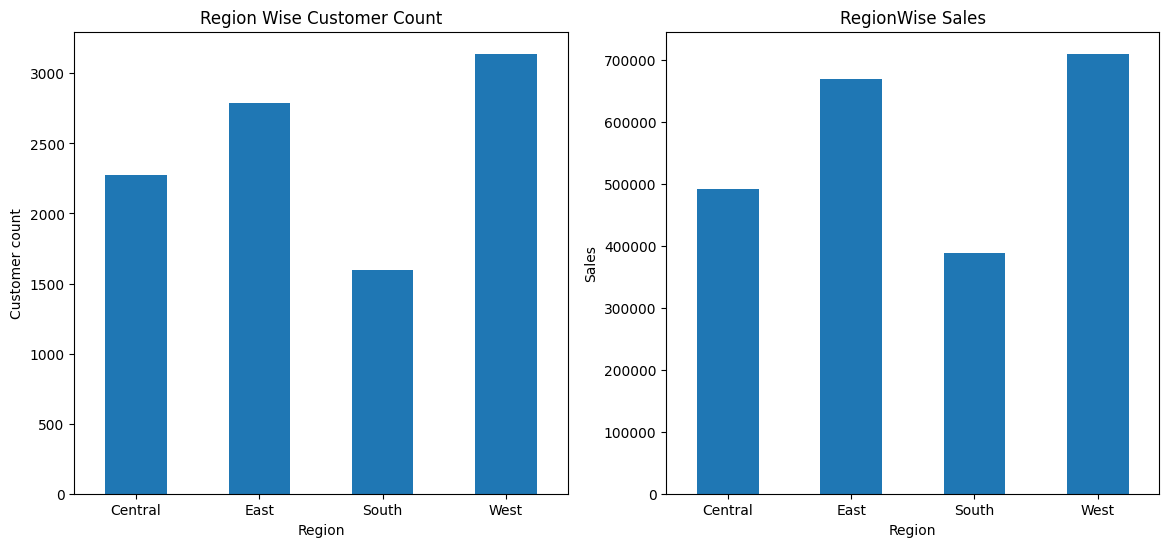

Region
Central    492646.91
East       669518.73
South      389151.46
West       710219.68
Name: Sales, dtype: float64
Region
Central    2277
East       2785
South      1598
West       3140
Name: Customer ID, dtype: int64


In [23]:
Total_Customers=Sales_Analysis.groupby('Region')['Customer ID'].count()
Region_Sales=Sales_Analysis.groupby('Region')['Sales'].sum().round(2)
fig,axis=plt.subplots(1,2,figsize=(14,6))
Total_Customers.plot(kind='bar',x='Region',y='Customer ID',ax=axis[0])
axis[0].set_title('Region Wise Customer Count')
axis[0].set_xlabel('Region')
axis[0].set_ylabel('Customer count')
axis[0].tick_params(axis='x',rotation=0)
Region_Sales.plot(kind='bar',x='Region',y='Sales',ax=axis[1])
axis[1].set_title('RegionWise Sales')
axis[1].set_xlabel('Region')
axis[1].set_ylabel('Sales')
axis[1].tick_params(axis='x',rotation=0)
plt.show()
print(Region_Sales)
print(Total_Customers)

Insights:
 1.West region had highest customers of 3140 and its sales is amount=7,10,219.68
 2.South region had lowest customers of 1598 and its sales is amount=3,89,151.46

In [24]:
##Highest Sale Region's Customer Count on Category

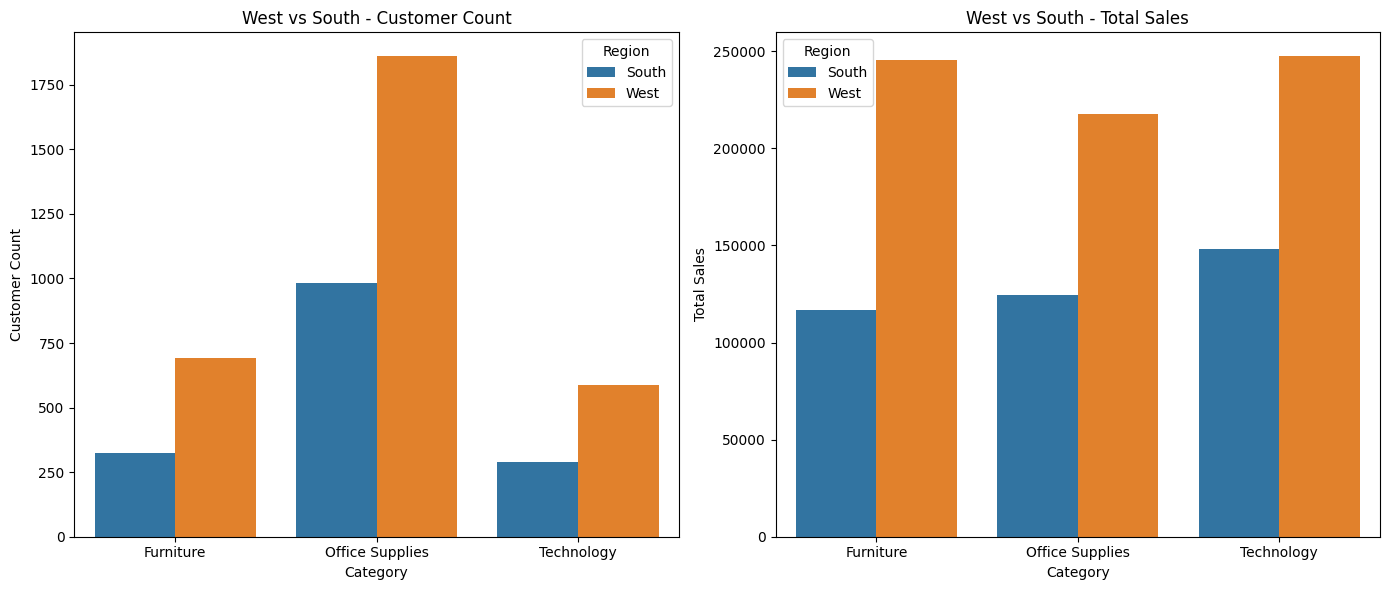

  Region         Category  Customer_Count  Total_Sales
0  South        Furniture             326    116531.48
1  South  Office Supplies             983    124424.77
2  South       Technology             289    148195.21
3   West        Furniture             691    245348.25
4   West  Office Supplies            1860    217466.51
5   West       Technology             589    247404.93


In [25]:
west_south = Sales_Analysis[Sales_Analysis['Region'].isin(['West', 'South'])]
west_sales = west_south.groupby(['Region', 'Category']).agg(
    Customer_Count=('Customer ID', 'count'),
    Total_Sales=('Sales', 'sum')
).round(2).reset_index()
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=west_sales, x='Category', y='Customer_Count', hue='Region', ax=axis[0])
axis[0].set_title('West vs South - Customer Count')
axis[0].set_xlabel('Category')
axis[0].set_ylabel('Customer Count')
axis[0].tick_params(axis='x', rotation=0)
sns.barplot(data=west_sales, x='Category', y='Total_Sales', hue='Region', ax=axis[1])
axis[1].set_title('West vs South - Total Sales')
axis[1].set_xlabel('Category')
axis[1].set_ylabel('Total Sales')
axis[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(west_sales)


Insights:
 1.In West Regions:
        Technology  is highest selling category for amount=2,47,404.93 at Customer Count of  589. 
        Furniture  is 2nd Highest Category for amount= 2,45,348.25 at Customer Count of 691 
 2.In South Regions:
        Technology  is highest selling category for amount=1,48,195.21 at Customer Count of 289     

In [26]:
print(Sales_Analysis['Order Date'].head())

0    2017-11-08
1    2017-11-08
2    2017-06-12
3    2016-10-11
4    2016-10-11
Name: Order Date, dtype: str


In [27]:
Sales_Analysis['Order Date'] = pd.to_datetime(
    Sales_Analysis['Order Date'], 
    format='%Y-%m-%d'
)

Sales_Analysis['Month'] = Sales_Analysis['Order Date'].dt.month
Sales_Analysis['Month_Name'] = Sales_Analysis['Order Date'].dt.month_name()
Sales_Analysis['Year']=Sales_Analysis['Order Date'].dt.year

print(Sales_Analysis[['Order Date', 'Month', 'Month_Name','Year']].head(10))

  Order Date  Month Month_Name  Year
0 2017-11-08     11   November  2017
1 2017-11-08     11   November  2017
2 2017-06-12      6       June  2017
3 2016-10-11     10    October  2016
4 2016-10-11     10    October  2016
5 2015-06-09      6       June  2015
6 2015-06-09      6       June  2015
7 2015-06-09      6       June  2015
8 2015-06-09      6       June  2015
9 2015-06-09      6       June  2015


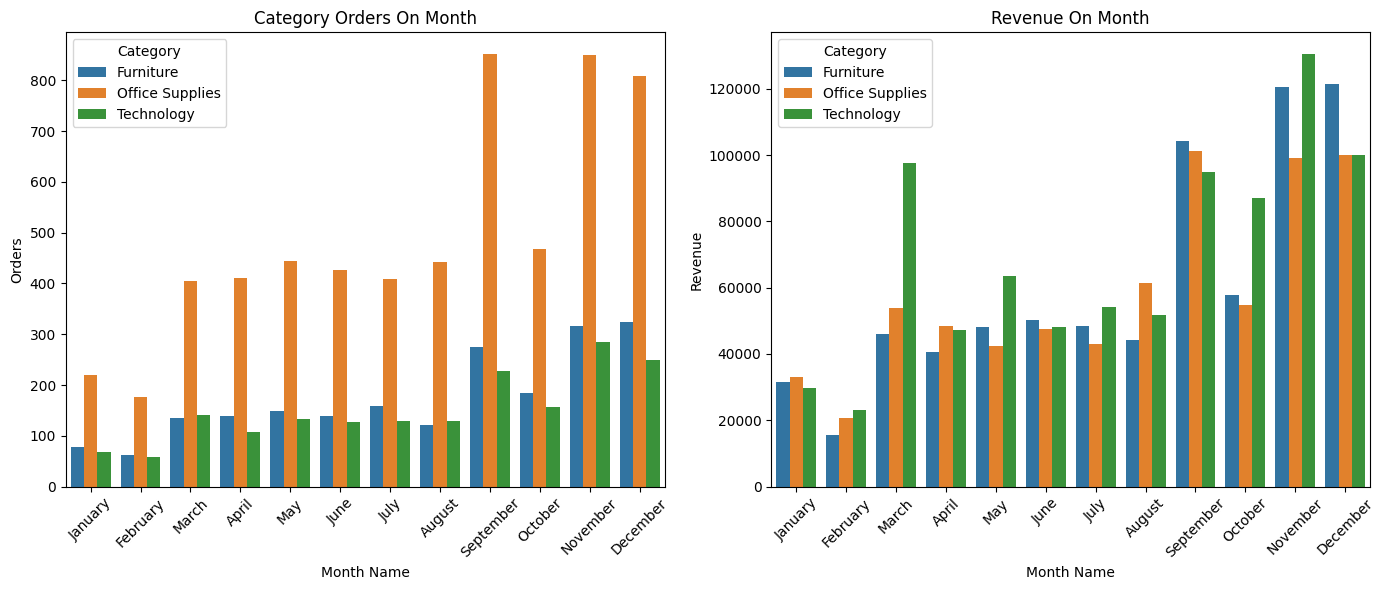

In [28]:
##Monthwise Orders:Revenue
# Step 1 - Group data
month_order = Sales_Analysis.groupby(['Category', 'Month_Name']).agg(
    Total_Orders=('Order ID', 'count'),
    Total_Revenue=('Sales', 'sum')
).round(2).reset_index()
month_cats = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']

month_order['Month_Name'] = pd.Categorical(
    month_order['Month_Name'],
    categories=month_cats,
    ordered=True
)
month_order = month_order.sort_values('Month_Name')
fig, axis = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=month_order, x='Month_Name', y='Total_Orders', 
            hue='Category', ax=axis[0])
axis[0].set_title('Category Orders On Month')
axis[0].set_xlabel('Month Name')
axis[0].set_ylabel('Orders')
axis[0].tick_params(axis='x', rotation=45)

sns.barplot(data=month_order, x='Month_Name', y='Total_Revenue', 
            hue='Category', ax=axis[1])
axis[1].set_title('Revenue On Month')
axis[1].set_xlabel('Month Name')
axis[1].set_ylabel('Revenue')
axis[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
                                                           

Insights:
   1.Office Supplies orders in  November month is 849 but its revenue is 99,155.64.
   2.On the other hand Technology order in November 284 but its revenue is  1,30,497.19 which is highest among all  
   3. low order placed month is March from Technology category order= 140 and its revenue is 97,500.39
   4.September had placed orders of 228 from Technology category but its revenue is lowest 94,`854.05

In [29]:
#Year Wise Order And Revenue 

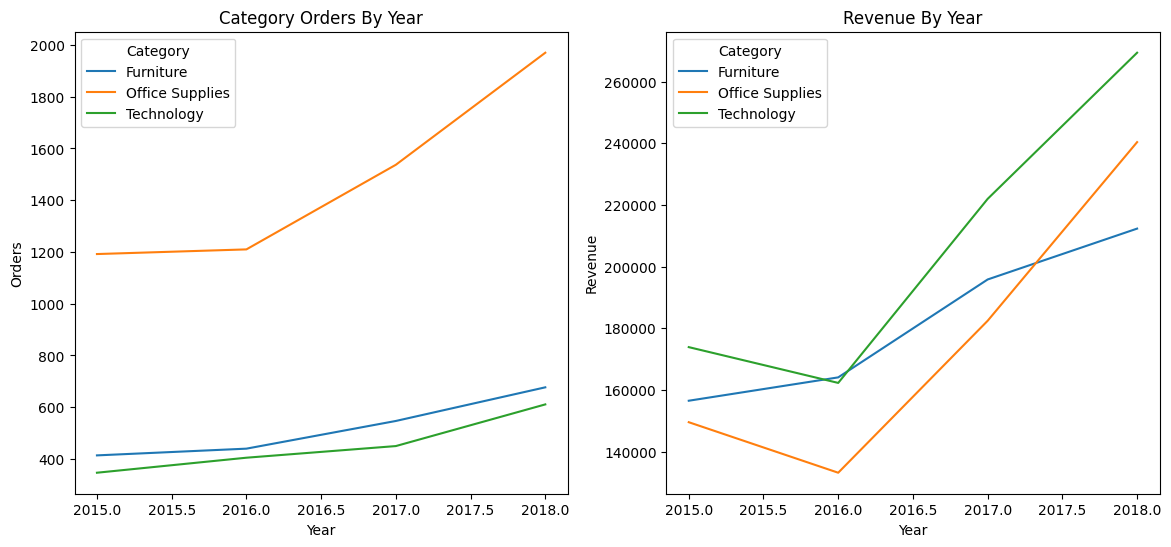

                      Total_orders  Total_Sales
Category        Year                           
Furniture       2015           414    156477.88
                2016           440    164053.87
                2017           547    195813.04
                2018           677    212313.79
Office Supplies 2015          1192    149512.82
                2016          1210    133124.41
                2017          1537    182417.57
                2018          1970    240367.54
Technology      2015           347    173865.51
                2016           405    162257.73
                2017           450    221961.94
                2018           611    269370.69


In [30]:
year_order= Sales_Analysis.groupby(['Category','Year']).agg(Total_orders=('Order ID','count'),Total_Sales=('Sales','sum') ).round(2)
fig,axis=plt.subplots(1,2,figsize=(14,6))
ax=sns.lineplot(data=year_order,x='Year',y='Total_orders',hue='Category',ax=axis[0])
ax.set_title('Category Orders By Year')
ax.set_xlabel('Year')
ax.set_ylabel('Orders')
ax1=sns.lineplot(data=year_order,x='Year',y='Total_Sales',hue='Category',ax=axis[1])
ax1.set_title('Revenue By Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue')
plt.show()
print(year_order)

Insights:
   In 2018 total orders received=1970 to Office Supplies and revenue earned is  2,40,367.54 which is second highest revenue generated. 
    top revenue generated is from 2018 at orders of 611  and revenue is 2,69,370.69 from Technology category


In [31]:
# Connect to SQLite (in memory — no file needed)
conn = sqlite3.connect(':memory:')

# ✅ Load your DataFrame directly into SQL table
Sales_Analysis.to_sql('Sales', conn, index=False, if_exists='replace')

print("Table loaded successfully!")

# Test it works
result = pd.read_sql("SELECT * FROM Sales LIMIT 5", conn)
print(result)

Table loaded successfully!
   Row ID        Order ID           Order Date   Ship Date       Ship Mode  \
0       1  CA-2017-152156  2017-11-08 00:00:00  11/11/2017    Second Class   
1       2  CA-2017-152156  2017-11-08 00:00:00  11/11/2017    Second Class   
2       3  CA-2017-138688  2017-06-12 00:00:00  16/06/2017    Second Class   
3       4  US-2016-108966  2016-10-11 00:00:00  18/10/2016  Standard Class   
4       5  US-2016-108966  2016-10-11 00:00:00  18/10/2016  Standard Class   

  Customer ID    Customer Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   

   ... Postal Code Region       Product I

In [32]:
##Total Sales By Category:

In [33]:
query="""
select  Category,
 round(sum(Sales),2) As Total_Sales
 From Sales
 Group by Category
 Order by Total_Sales desc
"""
result=pd.read_sql_query(query,conn)
result

,Category,Total_Sales
0,Technology,827455.87
1,Furniture,728658.58
2,Office Supplies,705422.33


In [34]:
## Customer Count Per region

In [35]:
query="""
select Region,
 count(distinct `Customer ID`) AS Total_Customer
 From Sales
 Group BY Region
 Order by Total_Customer desc


"""
result=pd.read_sql_query(query,conn)
result

,Region,Total_Customer
0,West,681
1,East,669
2,Central,626
3,South,509


In [36]:
## Average Sales Per Sub Category

In [37]:
query = """
select `Sub-Category`,
  round(Avg(Sales),2) As Average_Sales
  From Sales
  Group by `Sub-Category`
  order by Average_Sales desc



"""
result=pd.read_sql_query(query,conn)
result

,Sub-Category,Average_Sales
0,Copiers,2215.88
1,Machines,1645.55
2,Tables,645.89
3,Chairs,531.83
4,Bookcases,503.60
5,Phones,374.18
6,Storage,263.63
7,Supplies,252.28
8,Appliances,227.93
9,Accessories,217.18


In [38]:
## Greater than 500000 sales generating region

In [39]:
query="""
select Region,
  Round(sum(Sales),2) As Total_Sales
  From Sales
  Group by Region
  having Total_Sales > 500000 
  order by Total_Sales desc 

"""
result=pd.read_sql_query(query,conn)
result

,Region,Total_Sales
0,West,710219.68
1,East,669518.73


In [40]:
## year wise total order and revenue

In [41]:


query="""
select Year,
  count(`Order ID`) As Total_Order,
  Round(Sum(Sales),2) As Total_Revenue
  From Sales
  Group BY Year
  Order By Total_Order,Total_Revenue desc

"""
result=pd.read_sql_query(query,conn)
result

,Year,Total_Order,Total_Revenue
0,2015,1953,479856.21
1,2016,2055,459436.01
2,2017,2534,600192.55
3,2018,3258,722052.02


In [42]:
##Monthly Revenue For Each Category

In [43]:
query="""
select Category,Month_Name,
 round(sum(Sales),2) as Total_Sales
 From Sales
 Group by Category,Month_Name
 order by Total_Sales Desc
"""
result=pd.read_sql_query(query,conn)
result

,Category,Month_Name,Total_Sales
0,Technology,November,130497.19
1,Furniture,December,121462.03
2,Furniture,November,120508.88
3,Furniture,September,104174.08
4,Office Supplies,September,101075.28
5,Office Supplies,December,100026.76
6,Technology,December,99991.38
7,Office Supplies,November,99155.64
8,Technology,March,97500.39
9,Technology,September,94854.05


In [44]:
## Top 10 Cities By Sales

In [45]:
query="""
select City,
Round(sum(Sales),2) as Total_Sales
From Sales
Group by City
Order by Total_Sales desc 
limit 10
"""
result= pd.read_sql_query(query,conn)
result

,City,Total_Sales
0,New York City,252462.55
1,Los Angeles,173420.18
2,Seattle,116106.32
3,San Francisco,109041.12
4,Philadelphia,108841.75
5,Houston,63956.14
6,Chicago,47820.13
7,San Diego,47521.03
8,Jacksonville,44713.18
9,Detroit,42446.94


In [46]:
##Categories where Total Sales is Above Overall Average

In [47]:
query="""
select Category,
Round(sum(Sales),2) as Total_Sales,
round(Avg(Sales),2) as Average_Sales
From Sales
Group by Category
having Total_Sales >Average_Sales
order by Total_Sales,Average_Sales desc
"""
result=pd.read_sql_query(query,conn)
result

,Category,Total_Sales,Average_Sales
0,Office Supplies,705422.33,119.38
1,Furniture,728658.58,350.65
2,Technology,827455.87,456.40


In [48]:
##ranking region by sales 

In [49]:
query="""
select Region,
Round(sum(Sales),2) as Total_Sales, 
 Rank()over(Order by sum(Sales)desc)as rank
 From Sales
 group by Region
 
 




"""
result=pd.read_sql_query(query,conn)
result

,Region,Total_Sales,rank
0,West,710219.68,1
1,East,669518.73,2
2,Central,492646.91,3
3,South,389151.46,4


In [50]:
## New Column Adding 

In [51]:
query="""
select 
 case when Sales  >1000 Then 'High' Else 'low'end As Label
 From Sales
  limit 10
 



"""
result=pd.read_sql_query(query,conn)
result

,Label
0,low
1,low
2,low
3,low
4,low
5,low
6,low
7,low
8,low
9,low


In [52]:
##Best Seling Subcategory In Each Category

In [53]:
query = """
Select Category,`Sub-Category`, 
 Round(sum(Sales),2) As Total_Sales
 From Sales
 Group by Category,`Sub-Category`
 order BY Total_Sales desc
 """
result= pd.read_sql_query(query,conn)
result

,Category,Sub-Category,Total_Sales
0,Technology,Phones,327782.45
1,Furniture,Chairs,322822.73
2,Office Supplies,Storage,219343.39
3,Furniture,Tables,202810.63
4,Office Supplies,Binders,200028.79
5,Technology,Machines,189238.63
6,Technology,Accessories,164186.70
7,Technology,Copiers,146248.09
8,Furniture,Bookcases,113813.20
9,Office Supplies,Appliances,104618.40


In [54]:
##customer Who Order 2017 and 2018


In [55]:
query= """
Select `Customer Name` As Customer_Name,
 count(Distinct Year) as Year_ordered
 From Sales
 where year in(2017,2018)
 Group by Customer_Name
 having Count(distinct Year ) = 2
 order by Customer_Name
"""
result=pd.read_sql_query(query,conn)
result

,Customer_Name,Year_ordered
0,Aaron Hawkins,2
1,Aaron Smayling,2
2,Adam Bellavance,2
3,Adam Hart,2
4,Adam Shillingsburg,2
...,...,...
547,William Brown,2
548,Xylona Preis,2
549,Yoseph Carroll,2
550,Zuschuss Carroll,2


In [56]:
##Month Highest Revenue Of Each Year

In [57]:
query="""

select *from(
select Month_Name,Year,
Round(Sum(Sales),2) as Total_Revenue, 
 Rank() over ( partition by Year order by sum(Sales) desc) as Rank
 From Sales
 Group By Month_Name, Year
 )
where Rank = 1 
order by Year
"""
result=pd.read_sql_query(query,conn)
result

,Month_Name,Year,Total_Revenue,Rank
0,September,2015,81623.53,1
1,November,2016,75249.40,1
2,December,2017,95739.12,1
3,November,2018,117938.15,1


In [58]:
## running Total Of sales and Order By Date

In [59]:
query="""
select `Order Date` as Date,
 Round(sum(Sales),2) as Total_Sales,
 Sum(sum(Sales)) Over(Order by `Order Date`) as Running_Total,
 Count(`Order ID`) as Total_Orders
 From Sales
 Group by `Order Date`
order by `Order Date`
"""
result=pd.read_sql_query(query,conn)
result

,Date,Total_Sales,Running_Total,Total_Orders
0,2015-01-03 00:00:00,16.45,1.644800e+01,1
1,2015-01-04 00:00:00,288.06,3.045080e+02,3
2,2015-01-05 00:00:00,19.54,3.240440e+02,1
3,2015-01-06 00:00:00,4407.10,4.731144e+03,9
4,2015-01-07 00:00:00,87.16,4.818302e+03,2
...,...,...,...,...
1225,2018-12-26 00:00:00,814.59,2.256072e+06,4
1226,2018-12-27 00:00:00,177.64,2.256250e+06,2
1227,2018-12-28 00:00:00,1657.35,2.257907e+06,19
1228,2018-12-29 00:00:00,2915.53,2.260823e+06,12


In [60]:
##Top 3 Product By Sales In Each Category

In [61]:
query ="""
SELECT * FROM (
    SELECT Category, `Product Name`,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    RANK() OVER (PARTITION BY Category ORDER BY SUM(Sales) DESC) AS Rank
    FROM Sales
    GROUP BY Category, `Product Name`
)
WHERE Rank <= 3
ORDER BY Category, Rank
"""
result=pd.read_sql_query(query,conn)
result

,Category,Product Name,Total_Sales,Rank
0,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.58,1
1,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.97,2
2,Furniture,Bretford Rectangular Conference Table Tops,12995.29,3
3,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,1
4,Office Supplies,GBC DocuBind TL300 Electric Binding System,19823.48,2
5,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,3
6,Technology,Canon imageCLASS 2200 Advanced Copier,61599.82,1
7,Technology,Cisco TelePresence System EX90 Videoconferenci...,22638.48,2
8,Technology,Hewlett Packard LaserJet 3310 Copier,18839.69,3


In [62]:
## Comparision Of Each City Sales And Its Region

In [63]:
query = """
SELECT City, Region,
ROUND(SUM(Sales), 2) AS City_Sales,
ROUND(AVG(SUM(Sales)) OVER (PARTITION BY Region), 2) AS Region_Avg
FROM Sales
GROUP BY City, Region
ORDER BY Region, City_Sales DESC
LIMIT 10
"""
result=pd.read_sql_query(query,conn)
result

,City,Region,City_Sales,Region_Avg
0,Houston,Central,63956.14,2721.81
1,Chicago,Central,47820.13,2721.81
2,Detroit,Central,42446.94,2721.81
3,San Antonio,Central,21843.53,2721.81
4,Dallas,Central,20127.95,2721.81
5,Lafayette,Central,19624.51,2721.81
6,Minneapolis,Central,16870.54,2721.81
7,Jackson,Central,15420.04,2721.81
8,Springfield,Central,15051.38,2721.81
9,Milwaukee,Central,10469.04,2721.81


In [65]:
Sales_Analysis.to_csv("Sales_Analysis.csv", index=False)
print(" Successfully Saved")

 Successfully Saved
